In [1]:
import cv2
import os

img_dir = 'Croptimal/resnet/train/'

class_subdirs = [
    # Class 0
    # (subdir, weight)
    [('256_class_0', 1.0)],
    # Class 1
    [('256_class_1', 1.0)]]

n_classes = len(class_subdirs)
global_imgs = []

for i, class_data in enumerate(class_subdirs):
    global_imgs.append([])
    for subdir, weight in class_data:
        class_path = os.path.join(img_dir, subdir)
        for img_file in os.listdir(class_path):
            if img_file.endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                img_path = os.path.join(class_path, img_file)
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                if img is not None:
                    global_imgs[i].append(img)

for i in range(n_classes):
    print(f'Loaded {len(global_imgs[i])} images for class {i}')



Loaded 2258 images for class 0
Loaded 1390 images for class 1


In [2]:
import numpy as np
hist_0 = np.zeros((180, 256), dtype=np.float32)
hist_1 = np.zeros((180, 256), dtype=np.float32)
hue=[30, 50]
saturation=[120, 240]
count_range_0 = 0
count_range_1 = 0
remainingPixelCount = 0
totalPixelCount = 0
for label in range(n_classes):
    for img in global_imgs[label]:
        # convert image to HLS
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        # make histogram of H and S values
        hist = cv2.calcHist([hsv], [0, 1], None, [180, 256], [0, 180, 0, 256])
        if label == 0:
            hist_0 += hist
        else:
            hist_1 += hist
        mask = (
            (hsv[:, :, 0] >= hue[0]) & (hsv[:, :, 0] <= hue[1]) &
            (hsv[:, :, 1] >= saturation[0]) & (hsv[:, :, 1] <= saturation[1])
        )
        # filtered_img = img * mask[..., None]
        remainingPixelCount += mask.sum()
        totalPixelCount += mask.size
        if mask.any():
            if label == 0:
                count_range_0 += 1
            else:
                count_range_1 += 1

print(f'Class 0 images in range: {count_range_0}')
print(f'Class 1 images in range: {count_range_1}')
print(f'Remaining pixel count in range: {remainingPixelCount}')
print(f'Total pixel count: {totalPixelCount}')
print(f'Percentage of pixels in range: {100 * remainingPixelCount / totalPixelCount:.2f}%')
# normalize histograms
hist_0 = cv2.normalize(hist_0, hist_0).flatten()
hist_1 = cv2.normalize(hist_1, hist_1).flatten()

Class 0 images in range: 2258
Class 1 images in range: 1390
Remaining pixel count in range: 202752682
Total pixel count: 239075328
Percentage of pixels in range: 84.81%


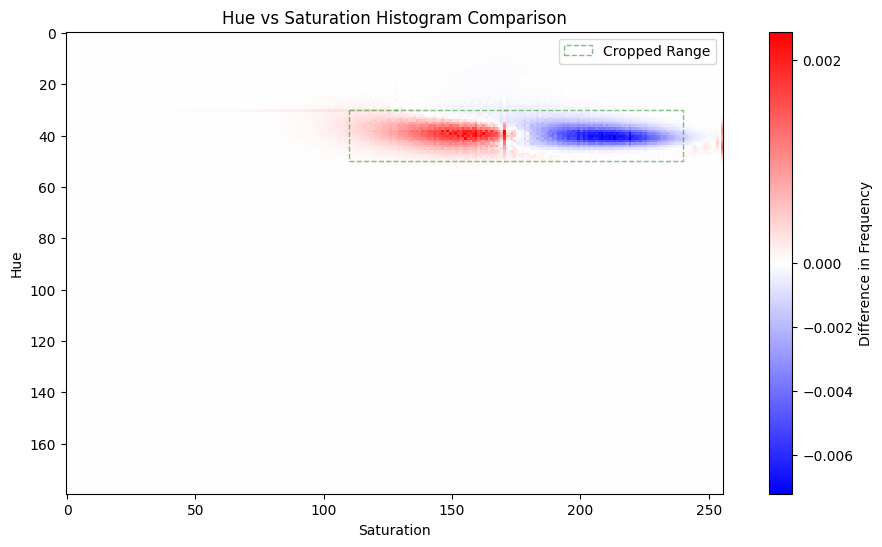

In [3]:
hue=[30, 50]
saturation=[110, 240]
# plot histograms
from matplotlib.colors import TwoSlopeNorm
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
# plot both histograms on same plot by subtracting one from the other as 2D histogram
diff = (hist_0 - hist_1).reshape(180, 256)
diff[0,0] = 0.0
np.save('histogram_diff.npy', diff)
# save the difference histogram in a file

norm = TwoSlopeNorm(
    vmin=diff.min(),
    vcenter=0.0,
    vmax=diff.max()
)
normalized = norm(diff)
plt.imshow(diff, cmap='bwr', interpolation='nearest', norm=norm)
plt.colorbar(label='Difference in Frequency')
plt.xlabel('Saturation')
plt.ylabel('Hue')
# plt.plot(hist_0 - hist_1, color='g', label='Difference Histogram')
plt.title('Hue vs Saturation Histogram Comparison')

# plot the cropping done from the hue and saturation ranges as a dotted rectangle on the histogram
rect = plt.Rectangle((saturation[0], hue[0]), saturation[1] - saturation[0], hue[1] - hue[0], edgecolor='green', facecolor='none', linewidth=1, linestyle='--', label='Cropped Range', alpha=0.5)
plt.gca().add_patch(rect)
plt.legend()
plt.show()

Text(0.5, 1.0, 'Hue vs Saturation Histogram Comparison')

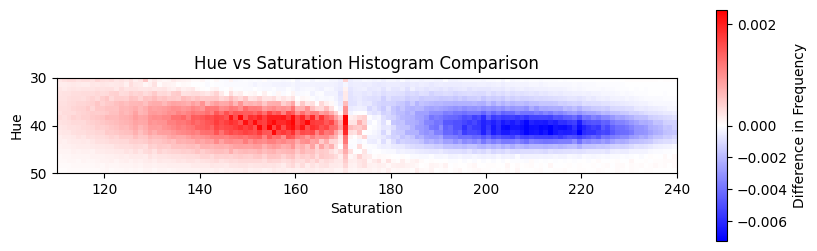

In [4]:
# plot histograms
plt.figure(figsize=(10, 3))
hue=[30, 50]
saturation=[110, 240]
cropped = (hist_0 - hist_1).reshape(180, 256)[hue[0]:hue[1], saturation[0]:saturation[1]]
cropped_norm = TwoSlopeNorm(
    vmin=cropped.min(),
    vcenter=0.0,
    vmax=cropped.max()
)
# hue=[0, 180]
# saturation=[120, 254]
# plot both histograms on same plot by subtracting one from the other as 2D histogram cropped to H=[60:100] and S=[75:250]
plt.imshow(cropped, cmap='bwr', interpolation='nearest', extent=[saturation[0], saturation[1], hue[1], hue[0]], norm=cropped_norm)
plt.colorbar(label='Difference in Frequency')
plt.xlabel('Saturation')
plt.ylabel('Hue')
# plt.plot(hist_0 - hist_1, color='g', label='Difference Histogram')
plt.title('Hue vs Saturation Histogram Comparison')

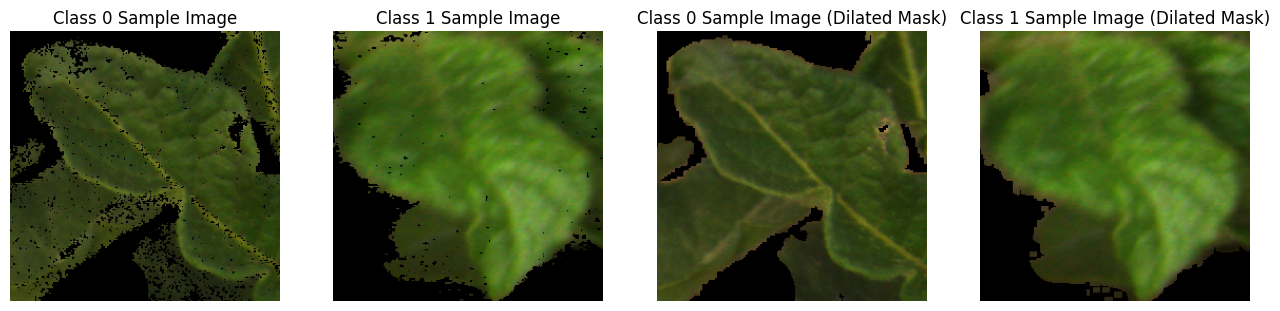

In [25]:
img0 = global_imgs[0][5]
hsv = cv2.cvtColor(img0, cv2.COLOR_RGB2HSV)
mask = (
    (hsv[:, :, 0] >= hue[0]) & (hsv[:, :, 0] <= hue[1]) &
    (hsv[:, :, 1] >= saturation[0]) & (hsv[:, :, 1] <= saturation[1])
)
img0_filtered = img0 * mask[..., None]

kernel = np.ones((5, 5), np.uint8)

dilated_mask = cv2.dilate(mask.astype(np.uint8), kernel, iterations=1)

img0_dilated = img0 * dilated_mask[..., None]

img1 = global_imgs[1][5]
hsv = cv2.cvtColor(img1, cv2.COLOR_RGB2HSV)
mask = (
    (hsv[:, :, 0] >= hue[0]) & (hsv[:, :, 0] <= hue[1]) &
    (hsv[:, :, 1] >= saturation[0]) & (hsv[:, :, 1] <= saturation[1])
)
img1_filtered = img1 * mask[..., None]

dilated_mask = cv2.dilate(mask.astype(np.uint8), kernel, iterations=1)

img1_dilated = img1 * dilated_mask[..., None]

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.imshow(img0_filtered)
plt.title('Class 0 Sample Image')
plt.axis('off')
plt.subplot(1, 4, 2)
plt.imshow(img1_filtered)
plt.title('Class 1 Sample Image')
plt.axis('off')
plt.subplot(1, 4, 3)
plt.imshow(img0_dilated)
plt.title('Class 0 Sample Image (Dilated Mask)')
plt.axis('off')
plt.subplot(1, 4, 4)
plt.imshow(img1_dilated)
plt.title('Class 1 Sample Image (Dilated Mask)')
plt.axis('off')
plt.show()

Non-zero pixels in filtered image: 44580119


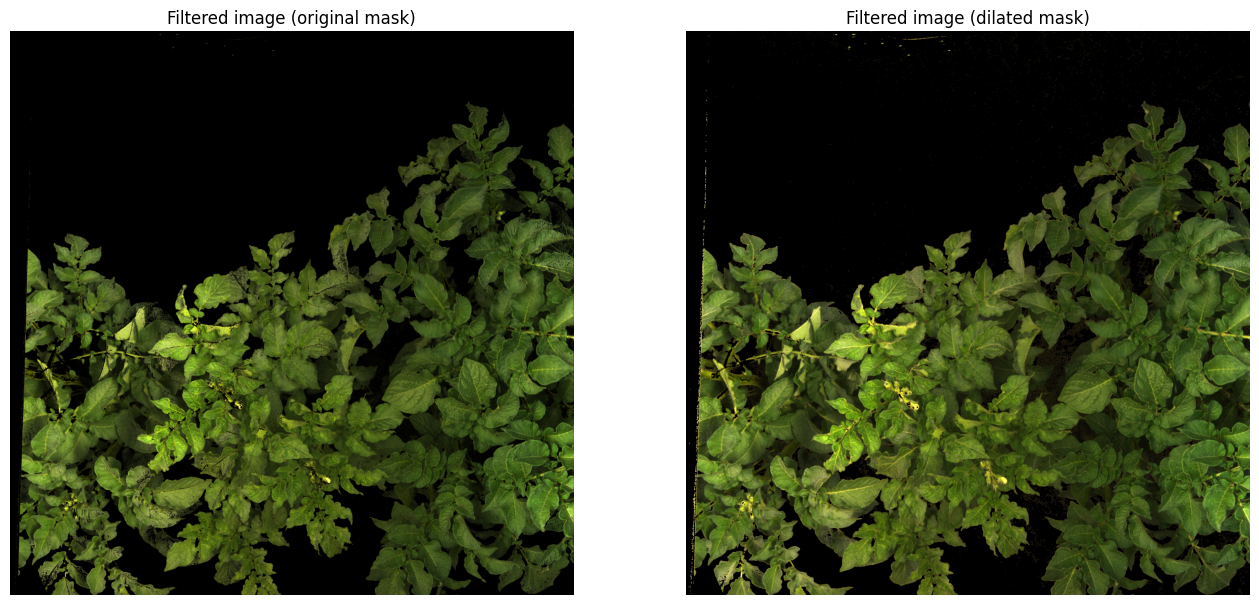

In [19]:
# Display an image with its filtered version based on hue and saturation constraints
img = cv2.imread('Croptimal/2024_5_13_CleansingDataset/Run1_light_normal_otherobjects/test/4e8ef493-3884-4645-82c6-4291a576684d.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

mask = (
    (hsv[:, :, 0] >= hue[0]) & (hsv[:, :, 0] <= hue[1]) &
    (hsv[:, :, 1] >= saturation[0]) & (hsv[:, :, 1] <= saturation[1])
)

kernel = np.ones((5, 5), np.uint8)

dilated_mask = cv2.dilate(mask.astype(np.uint8), kernel, iterations=1)

filtered_img_dilated = img * dilated_mask[..., None]

filtered_img = img * mask[..., None]

# print amount of non-zero pixels in filtered_img
print(f'Non-zero pixels in filtered image: {np.count_nonzero(filtered_img_dilated)}')

fig, ax = plt.subplots(1,2, figsize=(16, 8))
ax[0].imshow(filtered_img)
ax[0].set_title('Filtered image (original mask)')
ax[0].axis('off')
ax[1].imshow(filtered_img_dilated)
ax[1].set_title('Filtered image (dilated mask)')
ax[1].axis('off')

plt.show()

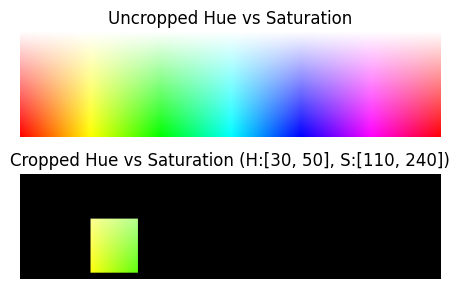

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(6, 3))

# OpenCV-compatible HSV ranges
hue2 = np.linspace(0, 360, 400, endpoint=False, dtype=np.float32)
sat2 = np.linspace(0, 1, 100, dtype=np.float32)
val = 1 * np.ones((100, 400), dtype=np.float32)

x, y = np.meshgrid(hue2, sat2)
hsv = np.stack((x, y, val), axis=2).astype(np.float32)


# Convert to RGB for display
img = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

axes[0].imshow(img)
axes[0].set_title('Uncropped Hue vs Saturation')
axes[0].axis('off')

hue_min, hue_max = hue[0]*2, hue[1]*2
sat_min, sat_max = saturation[0]/255, saturation[1]/255

mask_f = (
    (hsv[:,:,0] >= hue_min) & (hsv[:,:,0] <= hue_max) &
    (hsv[:,:,1] >= sat_min) & (hsv[:,:,1] <= sat_max)
)

# Convert boolean mask to float (0.0 or 1.0)
mask_f = mask_f.astype(np.float32)

# Apply mask (broadcast across RGB channels)
filtered_img_dilated = img * mask_f[..., None]

axes[1].imshow(filtered_img_dilated)
axes[1].set_title(
    f'Cropped Hue vs Saturation (H:[{hue[0]}, {hue[1]}], S:[{saturation[0]}, {saturation[1]}])'
)
axes[1].axis('off')

plt.tight_layout()
plt.show()


(5120, 5120) (5120, 5120) (180, 256)
Non-zero pixels in filtered image: 27855191


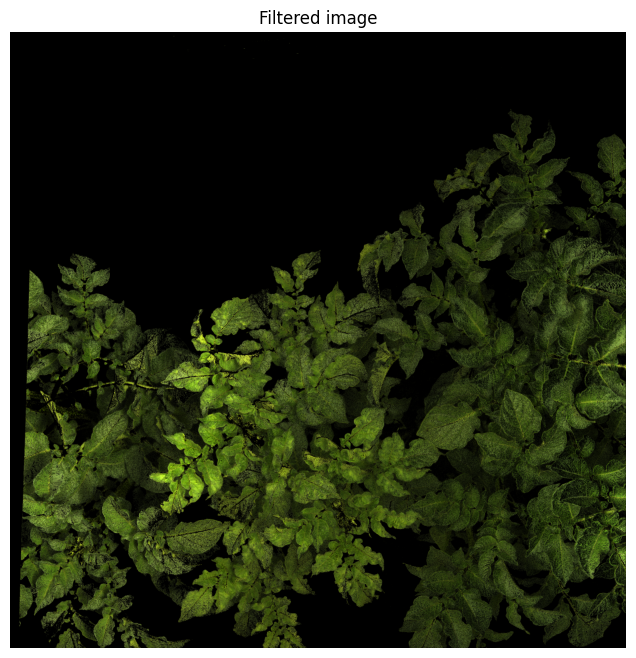

In [ ]:
hist = np.load('histogram_diff.npy')

img = cv2.imread('Croptimal/2024_5_13_CleansingDataset/Run1_light_normal_otherobjects/test/4e8ef493-3884-4645-82c6-4291a576684d.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

min_value = 0.0005

# make a mask where hue and saturation are filtered based on the min_value in the absolute histogram difference
hist_mask = (hist > min_value) | (hist < -min_value)
h = hsv[:, :, 0]
s = hsv[:, :, 1]

print(h.shape, s.shape, hist_mask.shape)

# If your histogram is indexed by H and S directly:
mask = hist_mask[h, s]

filtered_img_dilated = img * mask[..., None]

print(f'Non-zero pixels in filtered image: {np.count_nonzero(filtered_img_dilated)}')

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(filtered_img_dilated)
ax.set_title('Filtered image')
ax.axis('off')

plt.show()

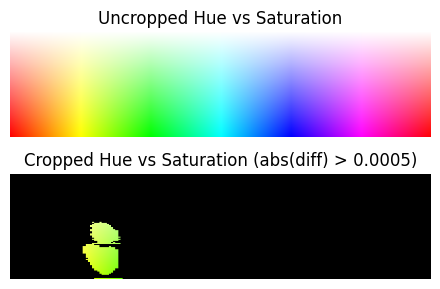

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(6, 3))

# OpenCV-compatible HSV ranges
hue2 = np.linspace(0, 360, 400, endpoint=False, dtype=np.float32)
sat2 = np.linspace(0, 1, 100, dtype=np.float32)
val = 1 * np.ones((100, 400), dtype=np.float32)

x, y = np.meshgrid(hue2, sat2)
hsv = np.stack((x, y, val), axis=2).astype(np.float32)


# Convert to RGB for display
img = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

axes[0].imshow(img)
axes[0].set_title('Uncropped Hue vs Saturation')
axes[0].axis('off')

hue_min, hue_max = hue[0]*2, hue[1]*2
sat_min, sat_max = saturation[0]/255, saturation[1]/255

hist_mask = (hist > min_value) | (hist < -min_value)
h = np.arange(180, dtype=np.int32)
s = np.arange(256, dtype=np.int32)

hh, ss = np.meshgrid(h, s, indexing='ij')  # shape (180, 256)

mask = hist_mask[hh, ss]

# Convert boolean mask to float (0.0 or 1.0)
mask_f = mask.astype(np.float32)

# Apply mask (broadcast across RGB channels)
hist_mask = (hist > min_value) | (hist < -min_value)

# Your visualization HSV (already created earlier)
# hsv shape = (100, 400, 3)

h_vis = hsv[:, :, 0]  # 0-360
s_vis = hsv[:, :, 1]  # 0-1

# Convert to OpenCV ranges
h_idx = (h_vis / 2).astype(np.int32)        # 0-179
s_idx = (s_vis * 255).astype(np.int32)      # 0-255

# Clip for safety
h_idx = np.clip(h_idx, 0, hist.shape[0] - 1)
s_idx = np.clip(s_idx, 0, hist.shape[1] - 1)

# Lookup mask from histogram
mask = hist_mask[h_idx, s_idx]

# Apply mask
filtered_img_dilated = img * mask[..., None]

axes[1].imshow(filtered_img_dilated)
axes[1].set_title(
    f'Cropped Hue vs Saturation (abs(diff) > {min_value})'
)
axes[1].axis('off')

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Hue vs Value (Saturation = 0)')

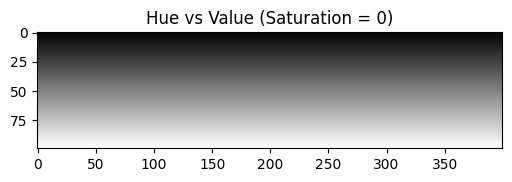

In [15]:
fig, axes = plt.subplots(1, 1, figsize=(6, 3))

# Hue range (same as before)
hue2 = np.linspace(0, 360, 400, endpoint=False, dtype=np.float32)

# Value range (vertical axis)
val = np.linspace(0, 1, 100, dtype=np.float32)

# Create grid
x, y = np.meshgrid(hue2, val)

# Saturation = 0 everywhere
sat2 = np.zeros_like(x, dtype=np.float32)

# HSV image
hsv = np.stack((x, sat2, y), axis=2).astype(np.float32)

# Convert to RGB
img = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

axes.imshow(img)
axes.set_title('Hue vs Value (Saturation = 0)')
# axes.axis('off')